# AVALIAÇÃO 2 - INTELIGÊNCIA ARTIFICIAL

1. Análise Exploratória com Foco em Redução de Complexidade.

* Realize a análise exploratória usual (distribuições, correlações, outliers, análise estatística e etc).

* Com base nas correlações e variâncias, proponha uma estratégia inicial para redução da dimensionalidade.

Justifique se usará normalização, padronização ou transformação específica antes do PCA.
Identifique possíveis atributos redundantes.

In [1]:
# Bibliotecas necessárias para análise dos dados

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


In [2]:
# Visualização dos dados

df = pd.read_csv("/content/wdbc.data", header=None)
df.columns =  [                        # Incluindo nomes as colunas do data set
    'id',
     'diagnostico', # Identificador do paciente # Diagnóstico M (Maligno) e B (Benigno)
    'raio_medio', 'textura_media', 'perimetro_medio', 'area_media', 'suavidade_media',
    'compacidade_media', 'concavidade_media', 'pontos_concavos_medios', 'simetria_media', 'dimensao_fractal_media',
    'raio_desvio', 'textura_desvio', 'perimetro_desvio', 'area_desvio', 'suavidade_desvio',
    'compacidade_desvio', 'concavidade_desvio', 'pontos_concavos_desvio', 'simetria_desvio', 'dimensao_fractal_desvio',
    'raio_pior', 'textura_pior', 'perimetro_pior', 'area_pior', 'suavidade_pior',
    'compacidade_pior', 'concavidade_pior', 'pontos_concavos_pior', 'simetria_pior', 'dimensao_fractal_pior'
]
df.head(11) # Retornar apenas as 10 primeiras linhas do dataset

,id,diagnostico,raio_medio,textura_media,perimetro_medio,area_media,suavidade_media,compacidade_media,concavidade_media,pontos_concavos_medios,...,raio_pior,textura_pior,perimetro_pior,area_pior,suavidade_pior,compacidade_pior,concavidade_pior,pontos_concavos_pior,simetria_pior,dimensao_fractal_pior
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.26540,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.18600,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.24300,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.25750,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.16250,0.2364,0.07678
5,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.17410,0.3985,0.12440
6,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,...,22.88,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.19320,0.3063,0.08368
7,84458202,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,...,17.06,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.15560,0.3196,0.11510
8,844981,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,...,15.49,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.20600,0.4378,0.10720
9,84501001,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,...,15.09,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.22100,0.4366,0.20750


In [3]:
# Análise exploratória / Estatística
print("Estatísticas descritivas")
print(df.describe()) # Retorno dos dados estatísticos do dataset

Estatísticas descritivas
                 id  raio_medio  textura_media  perimetro_medio   area_media  \
count  5.690000e+02  569.000000     569.000000       569.000000   569.000000   
mean   3.037183e+07   14.127292      19.289649        91.969033   654.889104   
std    1.250206e+08    3.524049       4.301036        24.298981   351.914129   
min    8.670000e+03    6.981000       9.710000        43.790000   143.500000   
25%    8.692180e+05   11.700000      16.170000        75.170000   420.300000   
50%    9.060240e+05   13.370000      18.840000        86.240000   551.100000   
75%    8.813129e+06   15.780000      21.800000       104.100000   782.700000   
max    9.113205e+08   28.110000      39.280000       188.500000  2501.000000   

       suavidade_media  compacidade_media  concavidade_media  \
count       569.000000         569.000000         569.000000   
mean          0.096360           0.104341           0.088799   
std           0.014064           0.052813           0.079720  

In [4]:
print(df.columns) # Quais colunas existem no dataset

Index(['id', 'diagnostico', 'raio_medio', 'textura_media', 'perimetro_medio',
       'area_media', 'suavidade_media', 'compacidade_media',
       'concavidade_media', 'pontos_concavos_medios', 'simetria_media',
       'dimensao_fractal_media', 'raio_desvio', 'textura_desvio',
       'perimetro_desvio', 'area_desvio', 'suavidade_desvio',
       'compacidade_desvio', 'concavidade_desvio', 'pontos_concavos_desvio',
       'simetria_desvio', 'dimensao_fractal_desvio', 'raio_pior',
       'textura_pior', 'perimetro_pior', 'area_pior', 'suavidade_pior',
       'compacidade_pior', 'concavidade_pior', 'pontos_concavos_pior',
       'simetria_pior', 'dimensao_fractal_pior'],
      dtype='object')


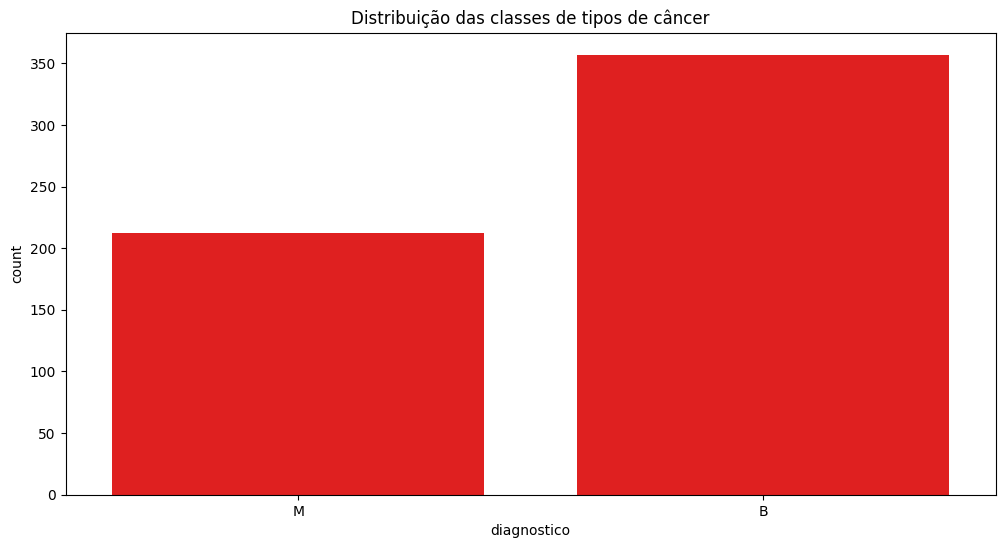

In [5]:
# Distribuição das classes de cancer ( M = Maligno, B = Benigno)
plt.figure(figsize=(12, 6)) # Tamanho do gráfico
sns.countplot(x='diagnostico', data=df, color = "red") # Amostras de M e B
plt.title("Distribuição das classes de tipos de câncer")
plt.show()

In [6]:
# Correlações de cada par de variável
x = df.iloc[:, 2:]
correlação_matrix = x.corr()
print(correlação_matrix)

                         raio_medio  textura_media  perimetro_medio  \
raio_medio                 1.000000       0.323782         0.997855   
textura_media              0.323782       1.000000         0.329533   
perimetro_medio            0.997855       0.329533         1.000000   
area_media                 0.987357       0.321086         0.986507   
suavidade_media            0.170581      -0.023389         0.207278   
compacidade_media          0.506124       0.236702         0.556936   
concavidade_media          0.676764       0.302418         0.716136   
pontos_concavos_medios     0.822529       0.293464         0.850977   
simetria_media             0.147741       0.071401         0.183027   
dimensao_fractal_media    -0.311631      -0.076437        -0.261477   
raio_desvio                0.679090       0.275869         0.691765   
textura_desvio            -0.097317       0.386358        -0.086761   
perimetro_desvio           0.674172       0.281673         0.693135   
area_d

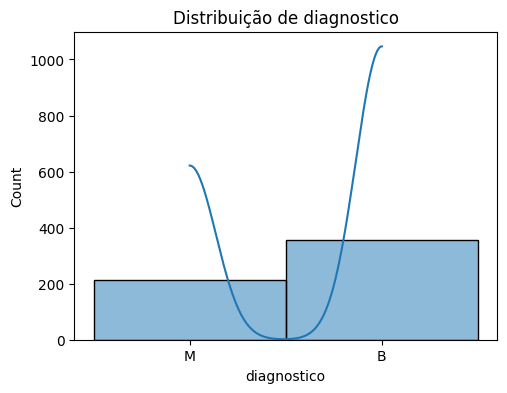

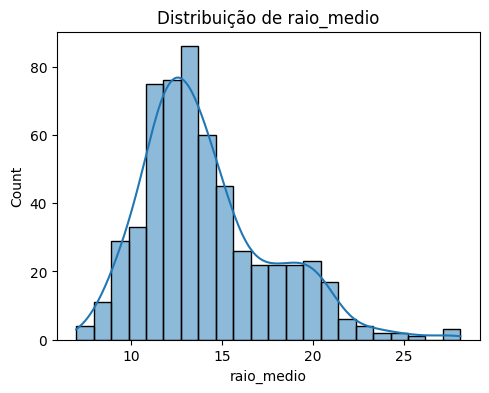

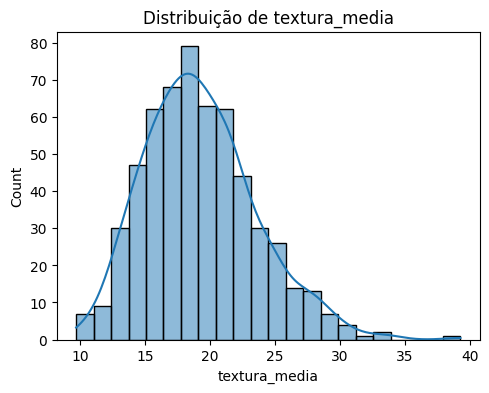

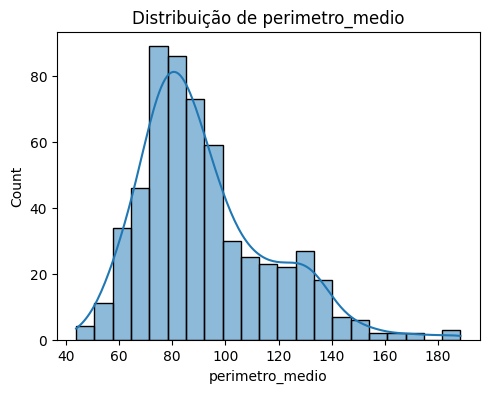

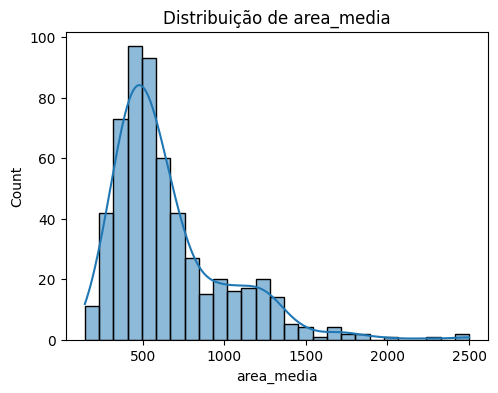

In [7]:
# Distribuição / Outliers por meio de histograma
cols_to_plot = df.columns[1:6]
for col in cols_to_plot:
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], kde = True)
    plt.title(f"Distribuição de {col}")
    plt.show()

Coluna: diagnostico is not numeric, skipping outlier detection.



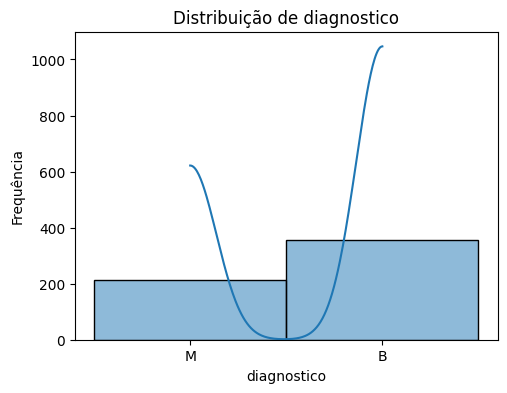

 Coluna: raio_medio
   Limite inferior: 5.58
   Limite superior: 21.90
   Total de outliers: 14
   Valores dos outliers:
[25.22 22.27 24.25 23.27 27.22 23.29 28.11 23.21 23.51 25.73 22.01 27.42
 23.09 24.63]



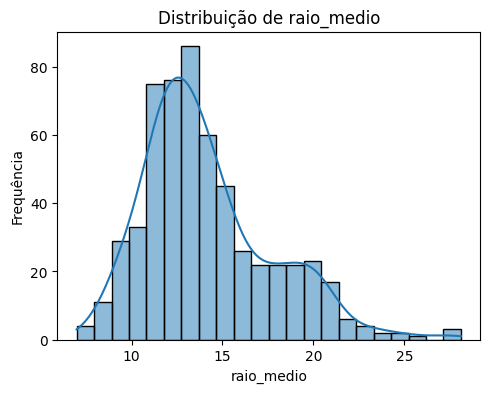

 Coluna: textura_media
   Limite inferior: 7.73
   Limite superior: 30.24
   Total de outliers: 7
   Valores dos outliers:
[32.47 33.81 39.28 33.56 31.12 30.72 30.62]



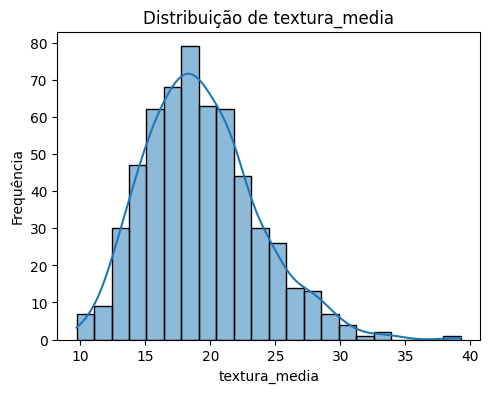

 Coluna: perimetro_medio
   Limite inferior: 31.78
   Limite superior: 147.49
   Total de outliers: 13
   Valores dos outliers:
[171.5 152.8 166.2 152.1 182.1 158.9 188.5 153.5 155.1 174.2 186.9 152.1
 165.5]



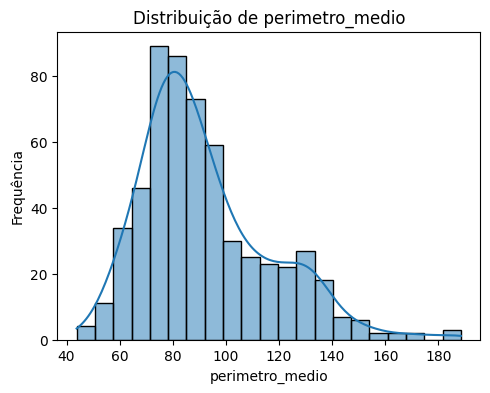

In [8]:
import matplotlib.pyplot as plt # Pra ver as médias / outliers das variáveis
import seaborn as sns
import numpy as np

cols_to_plot = df.columns[1:5]  # Selecione quantas colunas

for col in cols_to_plot:
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribuição de {col}")
    plt.xlabel(col)
    plt.ylabel("Frequência")


    if np.issubdtype(df[col].dtype, np.number):
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]

        print(f" Coluna: {col}")
        print(f"   Limite inferior: {lower_bound:.2f}")
        print(f"   Limite superior: {upper_bound:.2f}")
        print(f"   Total de outliers: {len(outliers)}")
        print(f"   Valores dos outliers:\n{outliers.values}\n")
    else:
        print(f"Coluna: {col} is not numeric, skipping outlier detection.\n")

    plt.show()

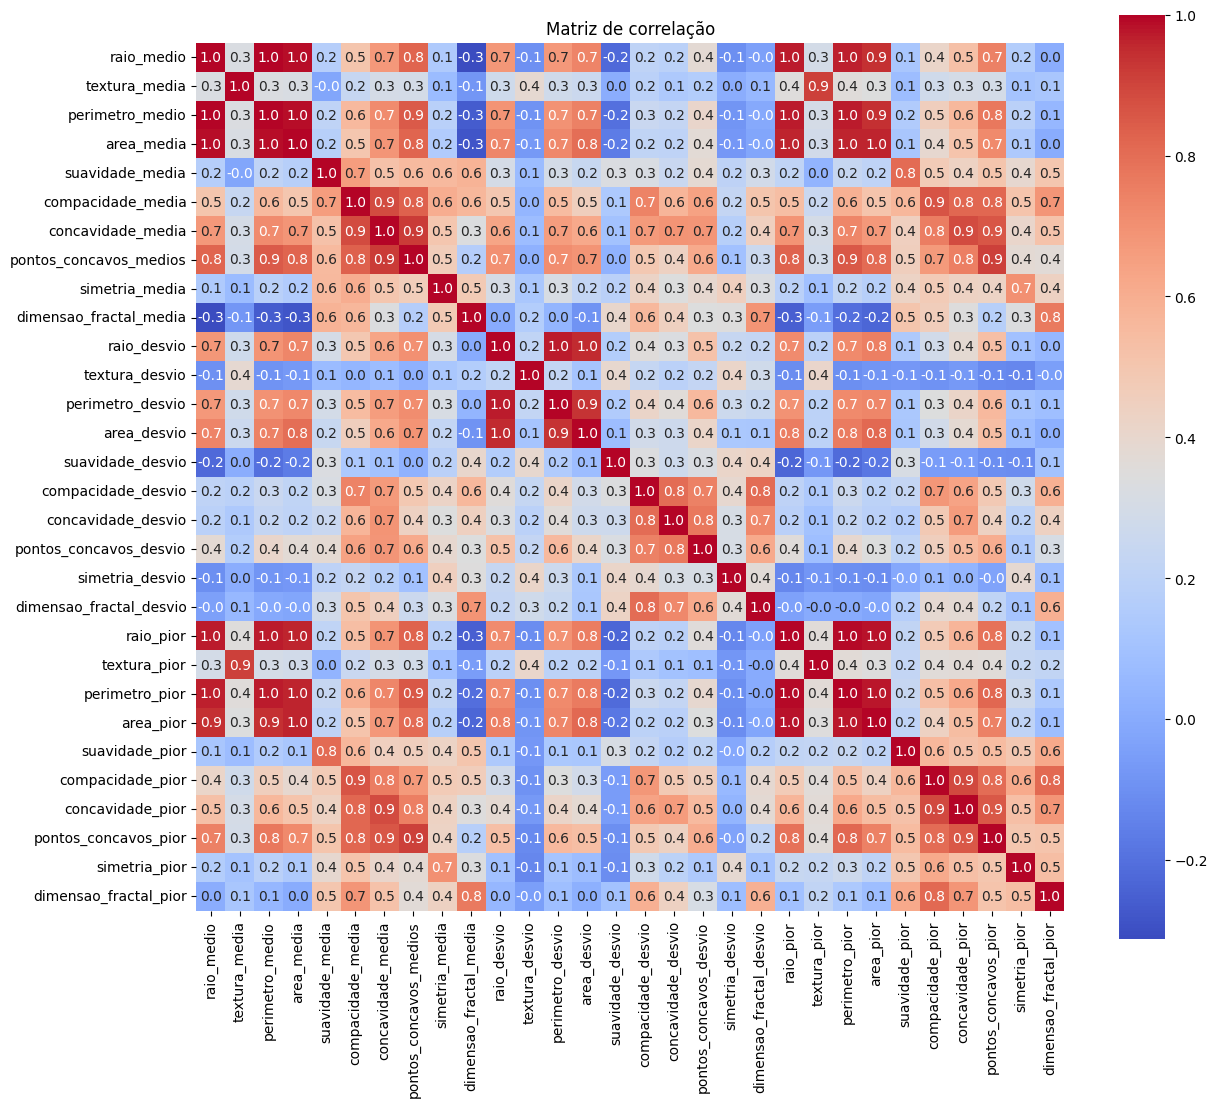

In [9]:
# Matriz de correlação
numeric_df = df.select_dtypes(include = np.number).drop(columns = ['id'])
corr = numeric_df.corr()
plt.figure(figsize=(14, 12))
sns.heatmap(corr, annot=True, fmt=".1f", cmap='coolwarm', square = True)
plt.title('Matriz de correlação')
plt.show()

In [10]:
# Os pares mais correlacionados entre si
pares_cor = 0.9
high_corr_var = np.where((corr > pares_cor) & (corr < 1 ))
high_corr_pares = [(corr.index[x], corr.columns[y], corr.iloc[x, y]) for x, y in zip(*high_corr_var) if x < y]
print("Atributos mais correlacionados")
for pares in high_corr_pares:
  print(pares)

Atributos mais correlacionados
('raio_medio', 'perimetro_medio', np.float64(0.9978552814938109))
('raio_medio', 'area_media', np.float64(0.9873571700566127))
('raio_medio', 'raio_pior', np.float64(0.9695389726112055))
('raio_medio', 'perimetro_pior', np.float64(0.9651365139559871))
('raio_medio', 'area_pior', np.float64(0.9410824595860461))
('textura_media', 'textura_pior', np.float64(0.912044588840421))
('perimetro_medio', 'area_media', np.float64(0.9865068039913907))
('perimetro_medio', 'raio_pior', np.float64(0.9694763634663146))
('perimetro_medio', 'perimetro_pior', np.float64(0.9703868870426394))
('perimetro_medio', 'area_pior', np.float64(0.9415498080023068))
('area_media', 'raio_pior', np.float64(0.9627460860470841))
('area_media', 'perimetro_pior', np.float64(0.9591195743552645))
('area_media', 'area_pior', np.float64(0.9592133256498998))
('concavidade_media', 'pontos_concavos_medios', np.float64(0.9213910263788588))
('pontos_concavos_medios', 'pontos_concavos_pior', np.float64

In [11]:
# Normalização utilizada StandardScaler
features = df.columns.drop(["id", "diagnostico"])
X = df[features]
Scaler = StandardScaler()
X_scaled = Scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns = features)
X_scaled.head(11)

,raio_medio,textura_media,perimetro_medio,area_media,suavidade_media,compacidade_media,concavidade_media,pontos_concavos_medios,simetria_media,dimensao_fractal_media,...,raio_pior,textura_pior,perimetro_pior,area_pior,suavidade_pior,compacidade_pior,concavidade_pior,pontos_concavos_pior,simetria_pior,dimensao_fractal_pior
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100
5,-0.476375,-0.835335,-0.387148,-0.505650,2.237421,1.244335,0.866302,0.824656,1.005402,1.890005,...,-0.165498,-0.313836,-0.115009,-0.244320,2.048513,1.721616,1.263243,0.905888,1.754069,2.241802
6,1.170908,0.160649,1.138125,1.095295,-0.123136,0.088295,0.300072,0.646935,-0.064325,-0.762332,...,1.368983,0.322883,1.368325,1.275220,0.518640,0.021215,0.509552,1.196716,0.262476,-0.014730
7,-0.118517,0.358450,-0.072867,-0.218965,1.604049,1.140102,0.061026,0.281950,1.403355,1.660353,...,0.163763,0.401048,0.099449,0.028859,1.447961,0.724786,-0.021054,0.624196,0.477640,1.726435
8,-0.320167,0.588830,-0.184080,-0.384207,2.201839,1.684010,1.219096,1.150692,1.965600,1.572462,...,-0.161357,0.822813,-0.031609,-0.248363,1.662757,1.818310,1.280035,1.391616,2.389857,1.288650
9,-0.473535,1.105439,-0.329482,-0.509063,1.582699,2.563358,1.738872,0.941760,0.797298,2.783096,...,-0.244190,2.443109,-0.286278,-0.297409,2.320295,5.112877,3.995433,1.620015,2.370444,6.846856


#-------------------------------------------------------------------------------

2. Redução de Dimensionalidade Múltipla: PCA vs T-SNE.

* Aplique PCA e T-SNE nos dados.

* Compare os dois métodos sob diferentes aspectos:

* Preservação da variância ou estrutura
* Custo computacional
* Capacidade de visualização de agrupamentos

Discuta vantagens e desvantagens de cada método no contexto do seu dataset.

In [12]:
# Aplicação do PCA

pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X_scaled)
print(f"Variância explicada PCA (2 componentes): {pca.explained_variance_ratio_.sum():.2%}")

Variância explicada PCA (2 componentes): 63.24%


In [13]:
# Aplicação do TSNE / Antes: 569, 32. Com t-SNE: 569, 2.

tsne = TSNE(n_components=2, perplexity = 30, random_state = 42, n_iter = 1000)
X_tsne = tsne.fit_transform(X_scaled)
print(X_tsne.shape)

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


(569, 2)


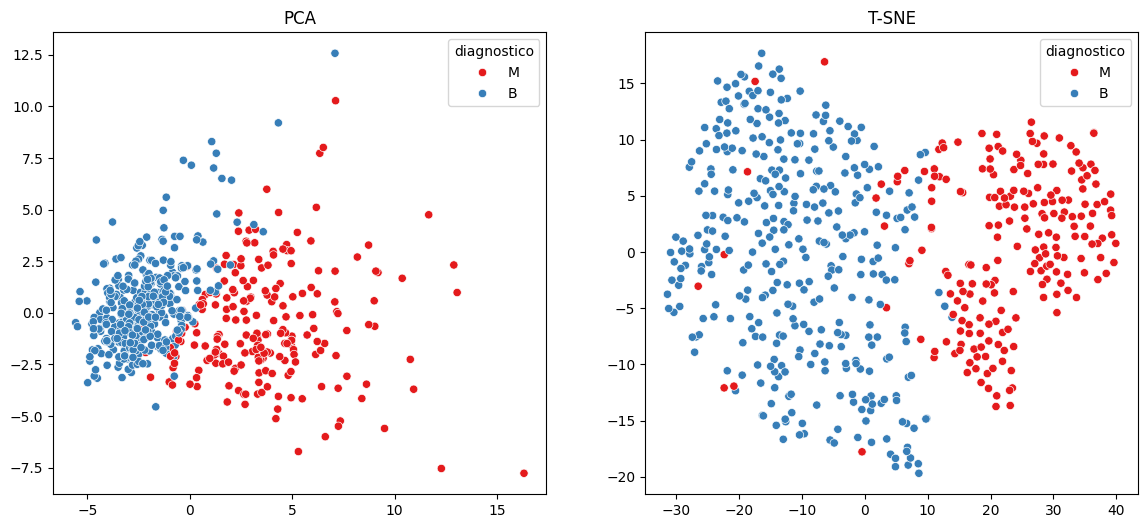

In [14]:
# Gráfico do PCA e T-SNE

X = df.select_dtypes(include=np.number).drop(columns=['id'])
y = df['diagnostico']

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y, palette='Set1', ax=ax[0])
ax[0].set_title("PCA")

sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=y, palette='Set1', ax=ax[1])
ax[1].set_title("T-SNE")

plt.show()

#-------------------------------------------------------------------------------

3. Clusterização com K-Means e Hierárquico

* Aplique dois métodos de clusterização:

* K-Means (com validação por inertia e silhouette score)
* Hierárquico (com pelo menos dois métodos de ligação – ex: average e complete)
* Compare os agrupamentos.

* Realize visualizações com projeção PCA ou T-SNE para cada método.

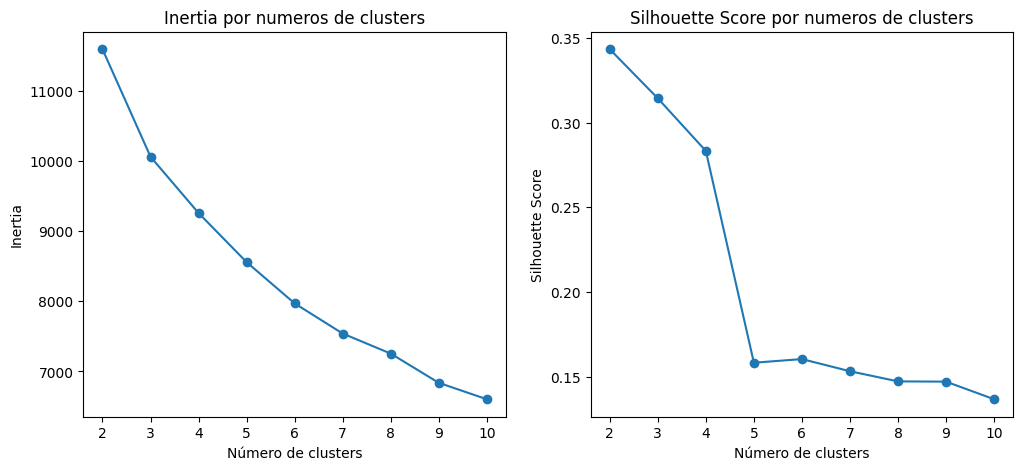

In [15]:
# K-Means com validação por Inertia e Silhouette.

inertias = []
silhouettes = []
k_values = range(2, 11)

for num_clusters in k_values:
    kmeans = KMeans(n_clusters = num_clusters, random_state = 42, n_init = 10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

# Inertia

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_values, inertias, "-o")
plt.title("Inertia por numeros de clusters")
plt.xlabel("Número de clusters")
plt.ylabel("Inertia")

# Silhouette

plt.subplot(1, 2, 2)
plt.plot(k_values, silhouettes, "-o")
plt.title("Silhouette Score por numeros de clusters")
plt.xlabel("Número de clusters")
plt.ylabel("Silhouette Score")

plt.show()

In [16]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

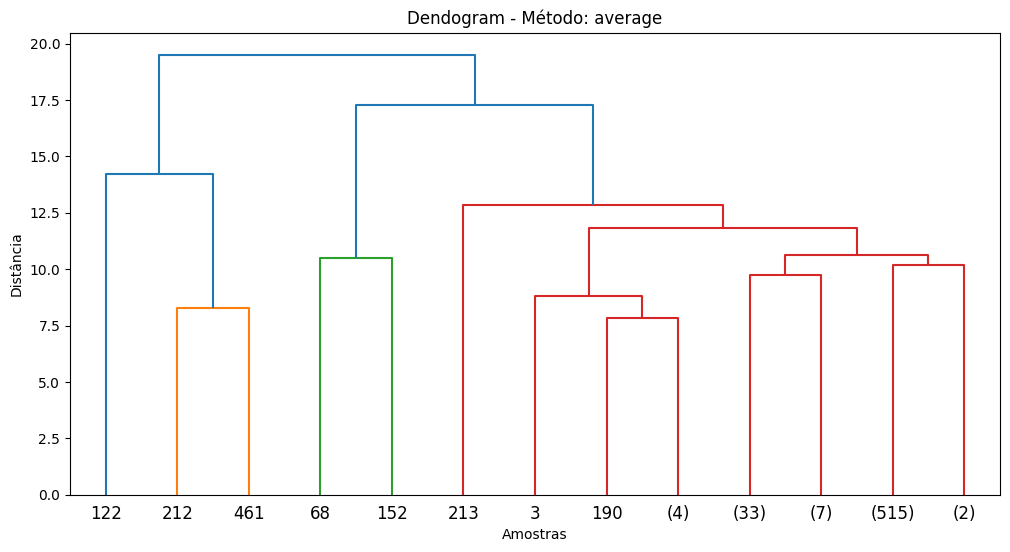

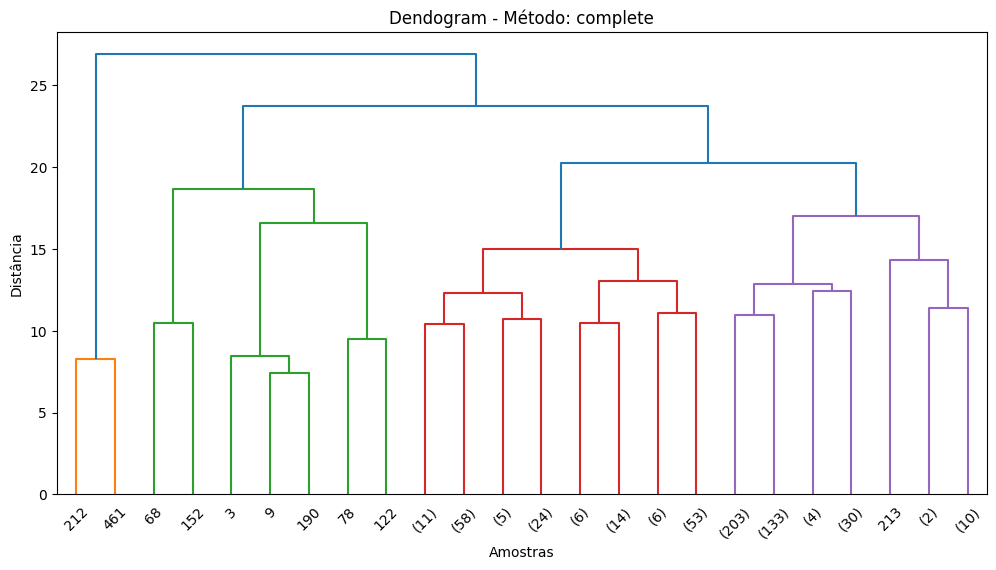

In [17]:
# Hierárquico (Average, Complete)
methods = ['average', 'complete']
for method in methods:
    xp = linkage(X_scaled, method = method)
    plt.figure(figsize = (12, 6))
    dendrogram(xp, truncate_mode = "level", p = 5)
    plt.title(f"Dendogram - Método: {method}")
    plt.xlabel("Amostras")
    plt.ylabel("Distância")
    plt.show()

    labels = fcluster(xp, 2, criterion='maxclust')
    if method == 'average':
        hier_labels_avg = labels
    else:
        hier_labels_complete = labels

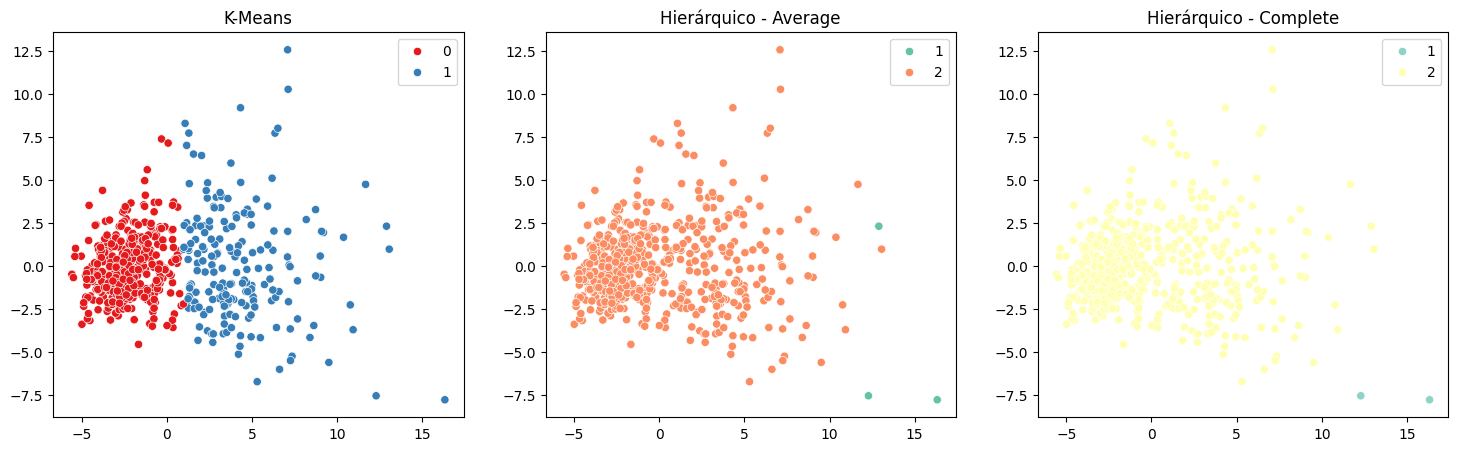

In [18]:
# Visualização com projeção PCA ou T-SNE prós métodos.

from sklearn.decomposition import PCA
import seaborn as sns

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1,3, figsize=(18,5))

sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=kmeans_labels, palette='Set1', ax=axes[0])
axes[0].set_title('K-Means')

sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=hier_labels_avg, palette='Set2', ax=axes[1])
axes[1].set_title('Hierárquico - Average')

sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=hier_labels_complete, palette='Set3', ax=axes[2])
axes[2].set_title('Hierárquico - Complete')

plt.show()


#-------------------------------------------------------------------------------

4.  Interpretação Semântica dos Agrupamentos.
Proponha um método para nomear ou interpretar semanticamente os clusters.

*   Escolha o metodo de clusterização adequada.
*   Utilize médias de variáveis por cluster, boxplots comparativos ou análise de centroides.
*   Aplique crosstab para avaliar o alinhamento.

In [19]:
# Método de clusterização julgado adequado, K-Means.
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

df_clusters = df.copy()
df_clusters['cluster'] = kmeans_labels  # rótulos do K-Means

cluster_means = df_clusters.groupby('cluster').mean(numeric_only = True)

print("Médias de cada cluster")
print(cluster_means)

Médias de cada cluster
                   id  raio_medio  textura_media  perimetro_medio  area_media  \
cluster                                                                         
0        2.601300e+07   12.426691      18.262427        79.820053  486.772267   
1        3.879741e+07   17.414536      21.275258       115.452887  979.857216   

         suavidade_media  compacidade_media  concavidade_media  \
cluster                                                          
0               0.091990           0.076585           0.042679   
1               0.104808           0.157993           0.177949   

         pontos_concavos_medios  simetria_media  ...  raio_pior  textura_pior  \
cluster                                          ...                            
0                      0.026155        0.172696  ...  13.768477     24.132933   
1                      0.092921        0.197526  ...  21.103041     28.662320   

         perimetro_pior    area_pior  suavidade_pior  compacid

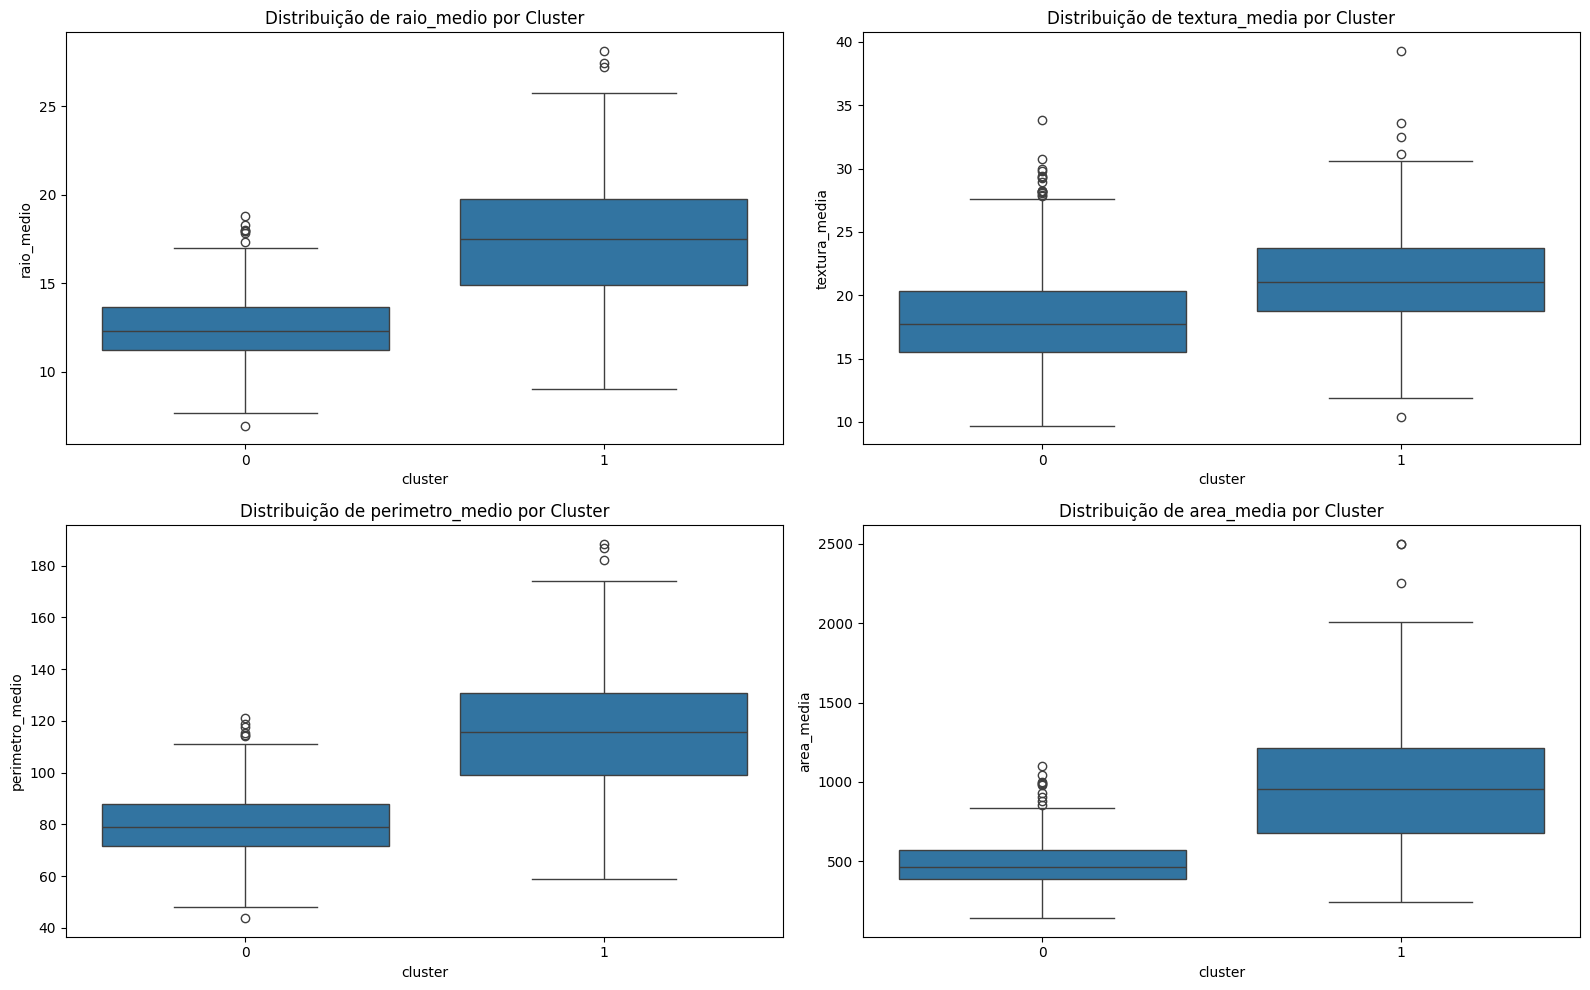

In [20]:
# Boxplot
import matplotlib.pyplot as plt
import seaborn as sns

variaveis_importantes = ['raio_medio', 'textura_media', 'perimetro_medio', "area_media"]

plt.figure(figsize=(16, 10))
for i, var in enumerate(variaveis_importantes, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='cluster', y=var, data=df_clusters)
    plt.title(f'Distribuição de {var} por Cluster')

plt.tight_layout()
plt.show()


In [21]:
# Centroides
centroide = pd.DataFrame(kmeans.cluster_centers_, columns = X.columns)
print(centroide)

   raio_medio  textura_media  perimetro_medio  area_media  suavidade_media  \
0   -0.482995      -0.239041        -0.500419   -0.478142        -0.311004   
1    0.933624       0.462065         0.967305    0.924243         0.601167   

   compacidade_media  concavidade_media  pontos_concavos_medios  \
0          -0.526019          -0.579036               -0.587171   
1           1.016789           1.119270                1.134996   

   simetria_media  dimensao_fractal_media  ...  raio_pior  textura_pior  \
0       -0.309084               -0.149141  ...  -0.517854     -0.251478   
1        0.597456                0.288288  ...   1.001006      0.486104   

   perimetro_pior  area_pior  suavidade_pior  compacidade_pior  \
0       -0.532311  -0.499358       -0.316078         -0.492241   
1        1.028953   0.965253        0.610976          0.951497   

   concavidade_pior  pontos_concavos_pior  simetria_pior  \
0         -0.536843             -0.580101      -0.303355   
1          1.03771

   raio_medio  textura_media  perimetro_medio  area_media  suavidade_media  \
0   -0.482995      -0.239041        -0.500419   -0.478142        -0.311004   
1    0.933624       0.462065         0.967305    0.924243         0.601167   

   compacidade_media  concavidade_media  pontos_concavos_medios  \
0          -0.526019          -0.579036               -0.587171   
1           1.016789           1.119270                1.134996   

   simetria_media  dimensao_fractal_media  ...  raio_pior  textura_pior  \
0       -0.309084               -0.149141  ...  -0.517854     -0.251478   
1        0.597456                0.288288  ...   1.001006      0.486104   

   perimetro_pior  area_pior  suavidade_pior  compacidade_pior  \
0       -0.532311  -0.499358       -0.316078         -0.492241   
1        1.028953   0.965253        0.610976          0.951497   

   concavidade_pior  pontos_concavos_pior  simetria_pior  \
0         -0.536843             -0.580101      -0.303355   
1          1.03771

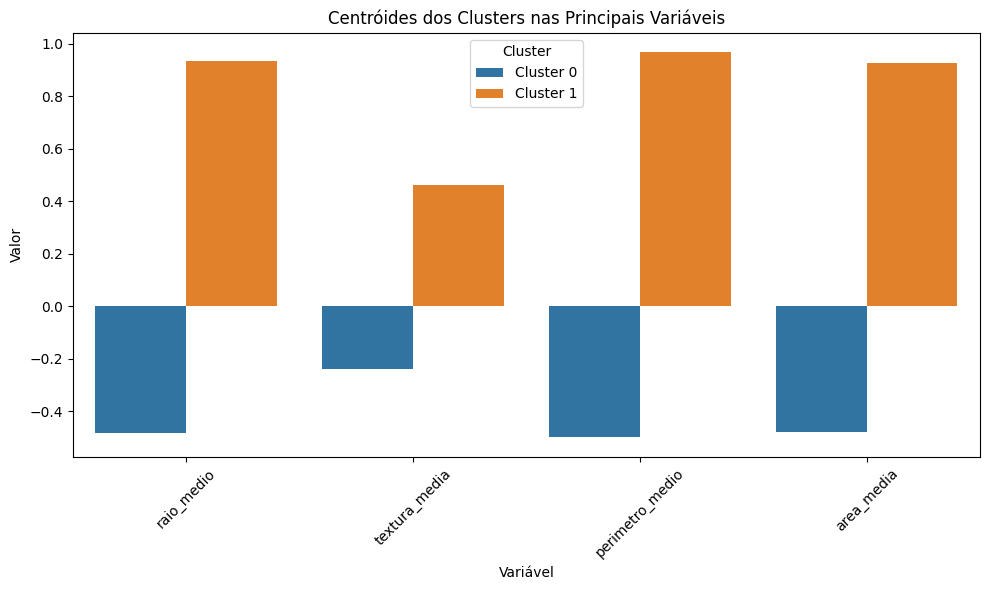

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

centroide = pd.DataFrame(kmeans.cluster_centers_, columns=X.columns)

print(centroide)

variaveis_principais = [
    'raio_medio',
    'textura_media',
    'perimetro_medio',
    'area_media', 
]

centroide_subset = centroide[variaveis_principais]

centroide_t = centroide_subset.T
centroide_t.columns = ['Cluster 0', 'Cluster 1']
centroide_t.reset_index(inplace=True)
centroide_t.rename(columns={'index': 'Variável'}, inplace=True)

plt.figure(figsize=(10, 6))
sns.barplot(data=pd.melt(centroide_t, id_vars='Variável',
                         value_vars=['Cluster 0', 'Cluster 1'],
                         var_name='Cluster', value_name='Valor'),
            x='Variável', y='Valor', hue='Cluster')

plt.title('Centróides dos Clusters nas Principais Variáveis')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [23]:
# Crosstab para avaliar o alinhamento
df_clusters['cluster_named'] = df_clusters['cluster'].map({0: 'Benigno', 1: 'Maligno'})
pd.crosstab(df_clusters['diagnostico'], df_clusters['cluster'])
ct = pd.crosstab(df_clusters['diagnostico'], df_clusters['cluster_named'])
print("\nTabela de contigencia entre diagnostico e cluster")
ct


Tabela de contigencia entre diagnostico e cluster


cluster_named,Benigno,Maligno
diagnostico,,
B,339,18
M,36,176


#-------------------------------------------------------------------------------

5. T-SNE ou PCA como Pré-processamento para Classificação
* Escolha uma variável atributo alvo para um modelo supervisionado.
* Avalie o desempenho da classificação com 3 possíveis cenários:
* com T-SNE,
* PCA,
* Nomalização apropriada.

Discuta se a clusterização ajudou a capturar informação relevante para o modelo supervisionado.

In [24]:
# Variável alvo será a diagnosis (M = Maligno, B = Benigno)

y = df["diagnostico"].map({"B": 0, "M":1})
x = df.select_dtypes(include = np.number).drop(columns = ["id"])

#print(y)
#print(x)

# Treino e teste

x_train, x_test, y_train, y_test = train_test_split(x, y, stratify = y, test_size = 0.2, random_state = 42)

# Normalização dos dados
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [25]:
# Classificação com normalização e KNN

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors = 5)
knn.fit(x_train_scaled, y_train)
y_pred_knn = y_pred = knn.predict(x_test_scaled)
acc_knn = accuracy_score(y_test, y_pred_knn)
print(f"Acurácia com KNN: {acc_knn:.2%}")

Acurácia com KNN: 95.61%


In [26]:
# PCA pós normalização
pca = PCA(n_components=2)
x_train_pca = pca.fit_transform(x_train_scaled)
x_test_pca = pca.transform(x_test_scaled)

clf_pca = LogisticRegression(max_iter=1000)
clf_pca.fit(x_train_pca, y_train)
y_pred_pca = clf_pca.predict(x_test_pca)
acc_pca = accuracy_score(y_test, y_pred_pca)

print(f"Acurácia com PCA: {acc_pca:.2%}")

Acurácia com PCA: 94.74%


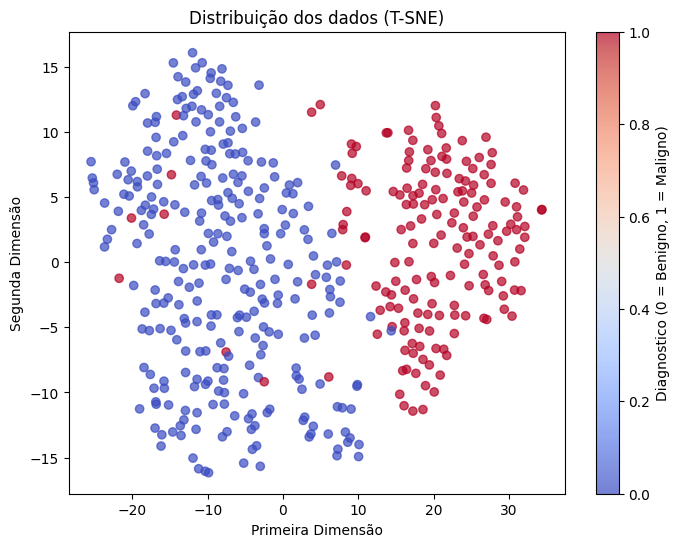

In [27]:
# T-SNE
tsne = TSNE(n_components=2, random_state=42)
x_train_tsne = tsne.fit_transform(x_train_scaled)

plt.figure(figsize = (8, 6))
plt.scatter(x_train_tsne[:, 0], x_train_tsne[:,1], c = y_train, cmap = "coolwarm", alpha =  0.7)
plt.title("Distribuição dos dados (T-SNE)")
plt.xlabel("Primeira Dimensão")
plt.ylabel("Segunda Dimensão")
plt.colorbar(label = "Diagnostico (0 = Benigno, 1 = Maligno)")
plt.show()